<a href="https://colab.research.google.com/github/rathoretina07/Deep-learning-/blob/main/lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
df = pd.read_csv("allDataMean.csv")

In [ ]:
print(df.columns)


Index(['allDataMean1', 'allDataMean2', 'allDataMean3', 'allDataMean4',
       'allDataMean5', 'allDataMean6', 'allDataMean7', 'allDataMean8',
       'allDataMean9', 'allDataMean10', 'allDataMean11', 'allDataMean12',
       'allDataMean13', 'allDataMean14', 'allDataMean15', 'allDataMean16'],
      dtype='object')


In [ ]:
df.head()


,allDataMean1,allDataMean2,allDataMean3,allDataMean4,allDataMean5,allDataMean6,allDataMean7,allDataMean8,allDataMean9,allDataMean10,allDataMean11,allDataMean12,allDataMean13,allDataMean14,allDataMean15,allDataMean16
0,3.327869,120.006557,0.968525,101.468852,59.978689,0.380328,0.873279,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3.000000,120.006557,0.972787,102.250820,59.990164,0.006230,0.876230,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.000000,120.037705,0.958689,100.242623,60.000000,0.020000,0.870328,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.000000,120.027869,0.944262,98.113115,59.963934,0.020000,0.865246,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.000000,120.037705,0.943115,97.857377,59.967213,0.020000,0.863115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [ ]:
target_column = 'your_target_column'
X = df.drop(columns=[target_column])
y = df[target_column]


In [ ]:
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(time_steps, len(X)):
        Xs.append(X[i-time_steps:i])
        ys.append(y.iloc[i])
    return np.array(Xs), np.array(ys)

# Create sequences
TIME_STEPS = 10
X_train_seq, y_train_seq = create_sequences(X_train, y_train, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, TIME_STEPS)


In [ ]:
import numpy as np

# Split scaled data into features and target
target_index = 0  # change this if your target column is not the first
scaled_target = scaled_data[:, target_index].reshape(-1, 1)
scaled_features = scaled_data[:, 1:]

# Now, later you will use only scaled_features for X, and scaled_target for y


In [ ]:
def create_sequences(features, target, time_steps):
    X, y = [], []
    for i in range(len(features) - time_steps):
        X.append(features[i:i + time_steps])
        y.append(target[i + time_steps])
    return np.array(X), np.array(y)


In [ ]:
# Example shape: X.shape = (samples, time_steps, features), y.shape = (samples, 1)
# Suppose you have a function create_sequences()
X, y = create_sequences(scaled_features, scaled_target, time_steps)


In [ ]:
y.shape

(184411, 16)

In [ ]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)


X_test shape: (27663, 15, 16)
y_test shape: (27663, 16)
y_pred shape: (442624, 1)


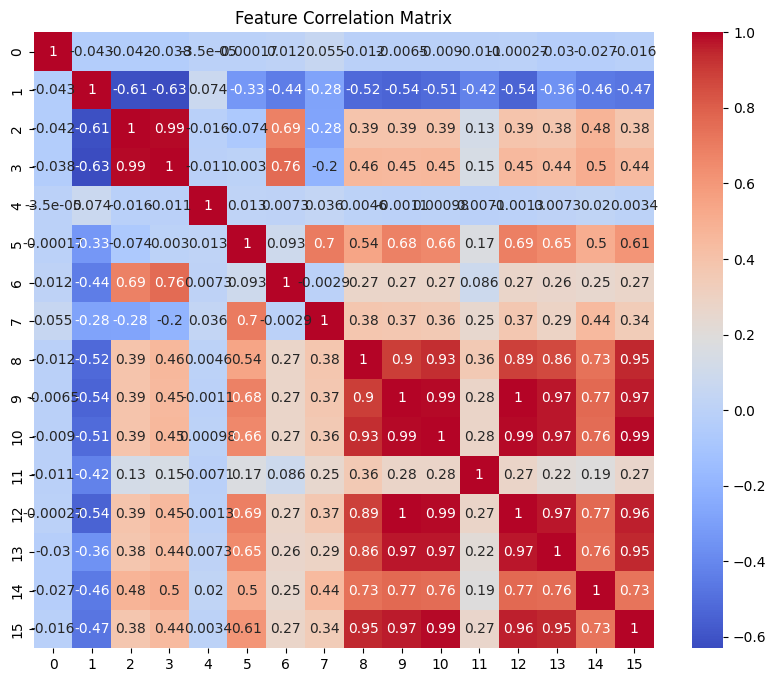

In [ ]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame(scaled_data)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. Scale the full dataset
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)  # df contains both features + targets

# 2. Separate features and targets
scaled_features = scaled_data[:, :-16]   # if your last 16 columns are targets
scaled_target = scaled_data[:, -16:]     # adjust based on your target columns

# 3. Create sequences (X, y)
X, y = create_sequences(scaled_features, scaled_target, time_steps)

# 4. Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [ ]:
total_samples = len(X)
train_size = int(0.7 * total_samples)
val_size = int(0.15 * total_samples)
X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (129087, 15, 16) (129087, 16)
Validation: (27661, 15, 16) (27661, 16)
Test: (27663, 15, 16) (27663, 16)


In [ ]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))
model.add(LSTM(32))
model.add(Dropout(0.3))
model.add(Dense(y_train.shape[1]))  # Assuming you are predicting all features

model.compile(optimizer='adam', loss='mse')
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 15, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,680 (131.56 KB)

 Trainable params: 33,680 (131.56 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 76s 18ms/step - loss: 0.0151 - val_loss: 0.0074
Epoch 2/100
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 70s 17ms/step - loss: 0.0031 - val_loss: 0.0073
Epoch 3/100
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 83s 18ms/step - loss: 0.0030 - val_loss: 0.0074
Epoch 4/100
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 81s 17ms/step - loss: 0.0030 - val_loss: 0.0077
Epoch 5/100
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - loss: 0.0030 - val_loss: 0.0082
Epoch 6/100
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 82s 18ms/step - loss: 0.0030 - val_loss: 0.0078
Epoch 7/100
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - loss: 0.0029 - val_loss: 0.0078
Epoch 8/100
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 71s 18ms/step - loss: 0.0029 - val_loss: 0.0125
Epoch 9/100
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 81s 17ms/step - loss: 0.0029 - val_loss: 0.0078
Epoch 10/100
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 76s 19ms/step - loss: 0.0029 - val_loss: 0.0078
Epoch 11/100
4034/4034 ━━━━━━━━━━━━━━━━━━━━ 76s 17ms/step - loss: 0.0029 - val_loss: 0.00

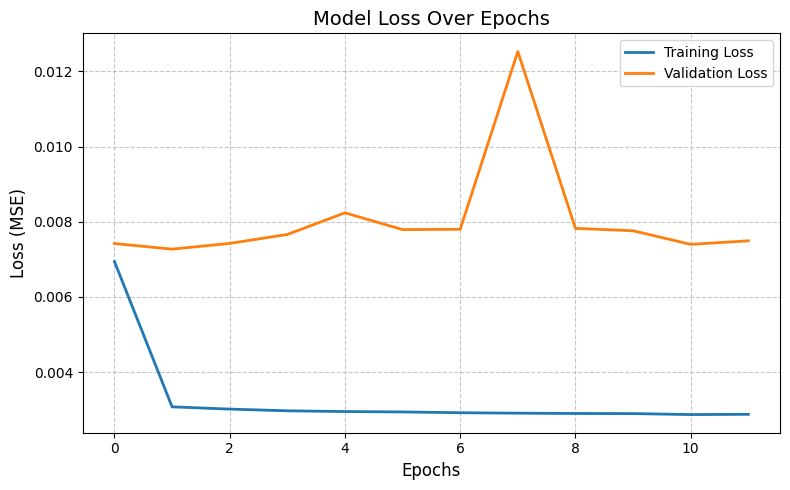

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)
plot_loss(history)


In [ ]:
predicted = model.predict(X_test)

InvalidArgumentError: Graph execution error:

Detected at node sequential_2_1/lstm_4_1/while/lstm_cell_1/MatMul defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/

In [ ]:
# Step 1: Reshape if needed
if y_pred.ndim == 1:
    y_pred = y_pred.reshape(-1, 1)
if y_test.ndim == 1:
    y_test = y_test.reshape(-1, 1)

# Step 2: Create dummy arrays
y_pred_dummy = np.zeros((y_pred.shape[0], scaled_data.shape[1]))
y_test_dummy = np.zeros((y_test.shape[0], scaled_data.shape[1]))

y_pred_dummy[:, 0] = y_pred[:, 0]
y_test_dummy[:, 0] = y_test[:, 0]

# Step 3: Inverse transform only the target
y_pred_inverse = scaler.inverse_transform(y_pred_dummy)[:, 0]
y_test_inverse = scaler.inverse_transform(y_test_dummy)[:, 0]


In [ ]:
print("Predicted shape:", predicted.shape)
print("Actual shape   :", y_test.shape)


Predicted shape: (27663, 16)
Actual shape   : (27663, 16)


In [ ]:
y_pred = model.predict(X_test)


865/865 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


In [ ]:
print("X_test shape:", X_test.shape)


X_test shape: (36883, 15, 0)


In [ ]:
print("Original data shape:", df.shape)
print("Original columns:", df.columns)


Original data shape: (184426, 16)
Original columns: RangeIndex(start=0, stop=16, step=1)


In [ ]:
print("Columns:", df.columns.tolist())


Columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


In [ ]:
# 5. Make predictions
y_pred = model.predict(X_test)

# ✅ Ensure shape match
print("Predicted shape:", y_pred.shape)
print("Actual shape   :", y_test.shape)

# 6. Inverse transform block (PLACE HERE ↓↓↓↓↓↓)

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create dummy arrays for inverse_transform
y_pred_dummy = np.zeros((y_pred.shape[0], scaled_data.shape[1]))
y_test_dummy = np.zeros((y_test.shape[0], scaled_data.shape[1]))

# Put predicted and actual target values in correct columns
y_pred_dummy[:, :y_pred.shape[1]] = y_pred
y_test_dummy[:, :y_test.shape[1]] = y_test

# Inverse transform
y_pred_inverse = scaler.inverse_transform(y_pred_dummy)[:, :y_pred.shape[1]]
y_test_inverse = scaler.inverse_transform(y_test_dummy)[:, :y_test.shape[1]]

# Calculate metrics
for i in range(y_pred_inverse.shape[1]):
    mae = mean_absolute_error(y_test_inverse[:, i], y_pred_inverse[:, i])
    rmse = mean_squared_error(y_test_inverse[:, i], y_pred_inverse[:, i], squared=False)
    r2 = r2_score(y_test_inverse[:, i], y_pred_inverse[:, i])
    print(f"Feature {i+1}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, R² = {r2:.4f}")


InvalidArgumentError: Graph execution error:

Detected at node sequential_2_1/lstm_4_1/while/lstm_cell_1/MatMul defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_inverse, y_pred_inverse)
rmse = mean_squared_error(y_test_inverse, y_pred_inverse, squared=False)
r2 = r2_score(y_test_inverse, y_pred_inverse)

print(f"MAE = {mae:.4f}, RMSE = {rmse:.4f}, R² = {r2:.4f}")


ValueError: Found input variables with inconsistent numbers of samples: [27663, 442624]

In [ ]:
# Select just one feature (e.g., Feature 6 = column index 5)
target_feature = scaled_data[:, 5].reshape(-1, 1)

# Prepare sequences
X, y = [], []
for i in range(time_steps, len(target_feature)):
    X.append(target_feature[i-time_steps:i])
    y.append(target_feature[i])
X, y = np.array(X), np.array(y)

# Train/test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Prediction & plot
y_pred = model.predict(X_test)
plt.figure(figsize=(10, 4))
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title("Single Feature Forecast - Feature 6")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def plot_loss(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title('Model Loss Over Epochs', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


865/865 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


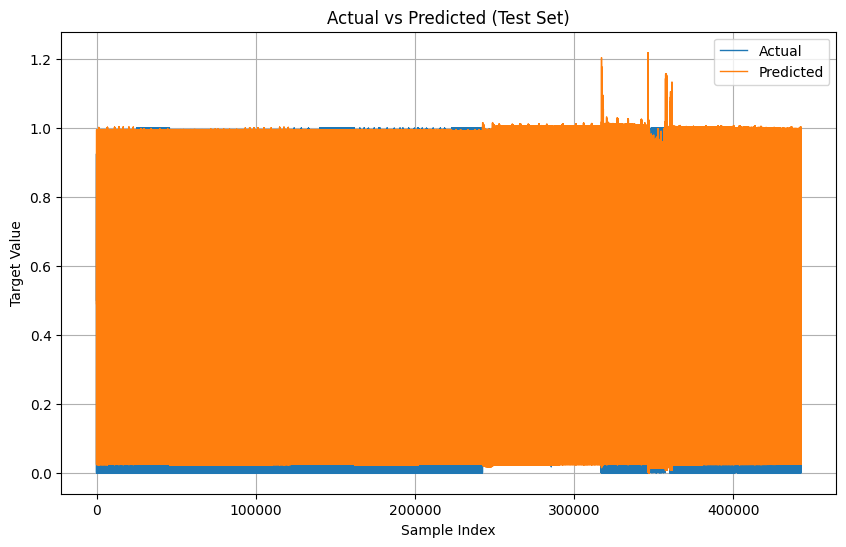

In [ ]:
y_pred = model.predict(X_test).flatten()
y_true = y_test.flatten()

plt.figure(figsize=(10, 6))
plt.plot(y_true, label='Actual', linewidth=1)
plt.plot(y_pred, label='Predicted', linewidth=1)
plt.title('Actual vs Predicted (Test Set)')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

for i in [0, 5, 6, 7]:  # Choose features that performed badly
    plt.figure(figsize=(10, 4))
    plt.plot(y_test_inverse[:, i], label='Actual')
    plt.plot(y_pred_inverse[:, i], label='Predicted')
    plt.title(f'Feature {i+1} - Actual vs Predicted')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.show()


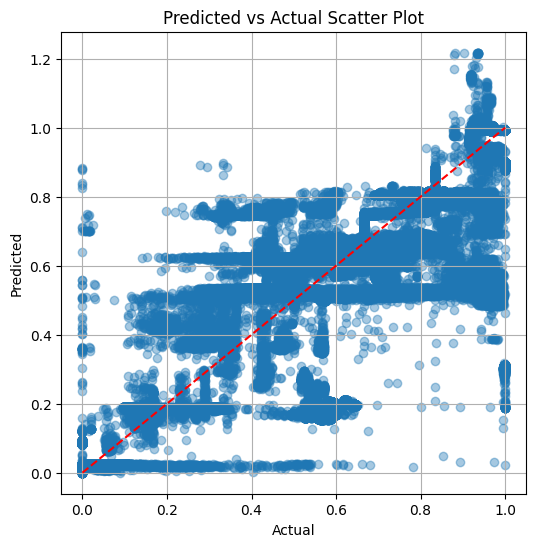

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.4)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')  # 45° line
plt.title('Predicted vs Actual Scatter Plot')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)
plt.show()


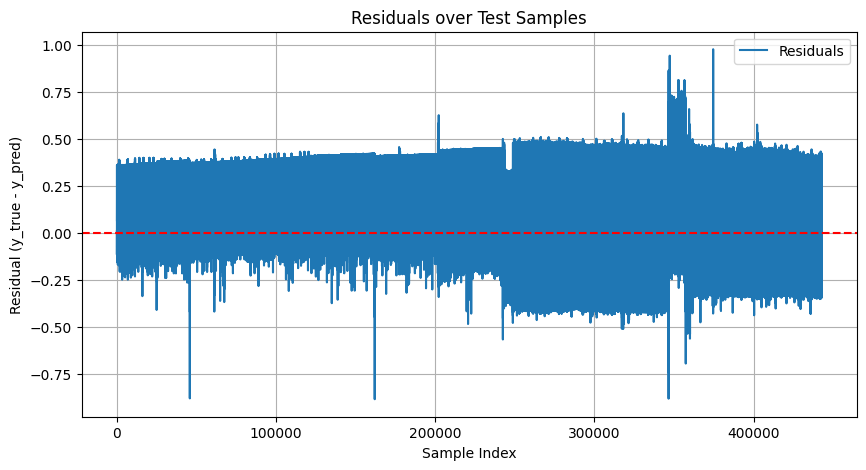

In [ ]:
residuals = y_true - y_pred

plt.figure(figsize=(10, 5))
plt.plot(residuals, label='Residuals')
plt.axhline(0, color='r', linestyle='--')
plt.title('Residuals over Test Samples')
plt.xlabel('Sample Index')
plt.ylabel('Residual (y_true - y_pred)')
plt.legend()
plt.grid(True)
plt.show()

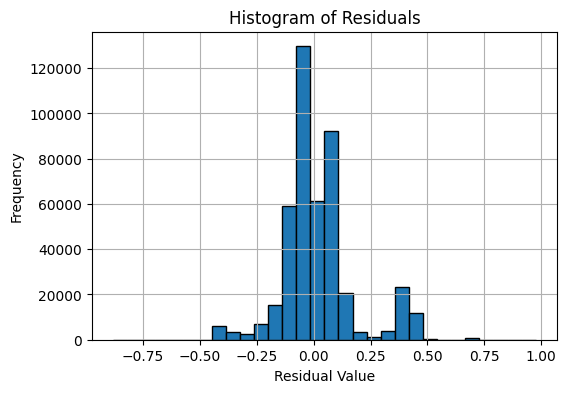

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()